In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [ ]:
SEED = 8888
MAX_SEQ_LENGTH = 2048

# NOTE: Fixes pad token = EOS and Qwen 2.5 chat template bugs
MODEL_NAME = "unsloth/Qwen2.5-Coder-3B-Instruct"

In [ ]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    dtype = None,
    load_in_4bit = True,
    model_name = MODEL_NAME,
    max_seq_length = MAX_SEQ_LENGTH,
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.1: Fast Qwen2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.05G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/613 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import json

dataset = []
with open("dataset.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        dataset.append(json.loads(line))

In [ ]:
dataset[0]

{'messages': [{'role': 'system',
   'content': "You are a text-to-SQL assistant. Output exactly one valid SQL query. Do not output natural language. Do not output multiple queries. Use only SELECT statements. Preserve column and table names casing. If irrelevant, output 'Please, try again'. "},
  {'role': 'user',
   'content': 'Given the schema: [{"table": "perpetrator", "columns": ["Perpetrator_ID", "People_ID", "Date", "Year", "Location", "Country", "Killed", "Injured"]}, {"table": "people", "columns": ["People_ID", "Name", "Height", "Weight", "Home Town"]}]. Answer the question: How many perpetrators are there?'},
  {'role': 'assistant', 'content': 'SELECT count(*) FROM perpetrator;'}]}

In [ ]:
from datasets import Dataset
from unsloth.chat_templates import get_chat_template, standardize_sharegpt

tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")
def formatting_prompts_func(examples):
    texts = []
    for messages in examples["messages"]:
        texts.append(
            tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=False,
            )
        )
    return {"text": texts}

dataset = Dataset.from_list(dataset)
dataset = dataset.map(formatting_prompts_func, batched=True)
dataset = standardize_sharegpt(dataset)

Map:   0%|          | 0/7701 [00:00<?, ? examples/s]

In [ ]:
dataset[0]["messages"]

[{'content': "You are a text-to-SQL assistant. Output exactly one valid SQL query. Do not output natural language. Do not output multiple queries. Use only SELECT statements. Preserve column and table names casing. If irrelevant, output 'Please, try again'. ",
  'role': 'system'},
 {'content': 'Given the schema: [{"table": "perpetrator", "columns": ["Perpetrator_ID", "People_ID", "Date", "Year", "Location", "Country", "Killed", "Injured"]}, {"table": "people", "columns": ["People_ID", "Name", "Height", "Weight", "Home Town"]}]. Answer the question: How many perpetrators are there?',
  'role': 'user'},
 {'content': 'SELECT count(*) FROM perpetrator;', 'role': 'assistant'}]

In [ ]:
dataset[0]["text"]

'<|im_start|>system\nYou are a text-to-SQL assistant. Output exactly one valid SQL query. Do not output natural language. Do not output multiple queries. Use only SELECT statements. Preserve column and table names casing. If irrelevant, output \'Please, try again\'. <|im_end|>\n<|im_start|>user\nGiven the schema: [{"table": "perpetrator", "columns": ["Perpetrator_ID", "People_ID", "Date", "Year", "Location", "Country", "Killed", "Injured"]}, {"table": "people", "columns": ["People_ID", "Name", "Height", "Weight", "Home Town"]}]. Answer the question: How many perpetrators are there?<|im_end|>\n<|im_start|>assistant\nSELECT count(*) FROM perpetrator;<|im_end|>\n'

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    bias = "none",
    lora_alpha = 16,
    lora_dropout = 0,
    random_state = SEED,
    use_rslora = False,
    loftq_config = None,
    use_gradient_checkpointing = "unsloth",
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
)

Unsloth 2026.1.1 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


In [ ]:
from trl import SFTConfig, SFTTrainer
from transformers import DataCollatorForSeq2Seq

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = MAX_SEQ_LENGTH,
    data_collator = DataCollatorForSeq2Seq(tokenizer=tokenizer),
    packing = False,
    args = SFTConfig(
        seed = SEED,
        max_steps = 50,
        warmup_steps = 5,
        logging_steps = 1,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        weight_decay = 0.001,
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        lr_scheduler_type = "linear",
        optim = "paged_adamw_8bit",
        output_dir = "outputs",
        report_to = "none",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=4):   0%|          | 0/7701 [00:00<?, ? examples/s]

In [ ]:
from unsloth.chat_templates import train_on_responses_only

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)

Map (num_proc=6):   0%|          | 0/7701 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 7,701 | Num Epochs = 1 | Total steps = 50
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 29,933,568 of 3,115,872,256 (0.96% trained)


Step,Training Loss
1,0.920600
2,0.742400
3,0.445200
4,0.701700
5,0.453700
6,0.468800
7,0.240900
8,0.253300
9,0.102900
10,0.115400


Unsloth: Will smartly offload gradients to save VRAM!


TrainOutput(global_step=50, training_loss=0.24856743052601815, metrics={'train_runtime': 163.4104, 'train_samples_per_second': 1.224, 'train_steps_per_second': 0.306, 'total_flos': 1053380759420928.0, 'train_loss': 0.24856743052601815, 'epoch': 0.025970653161927024})

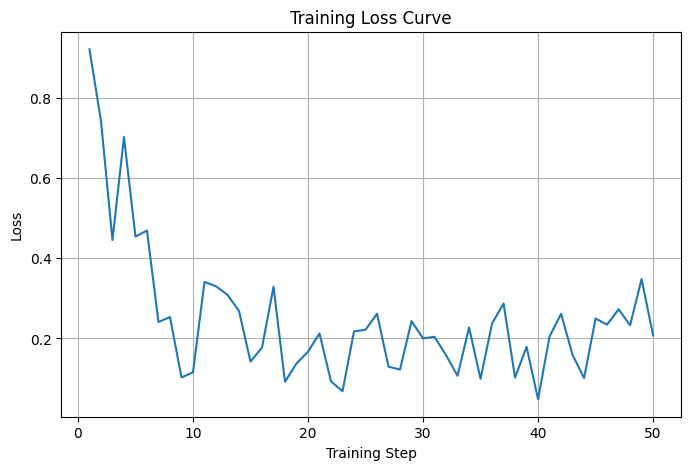

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps = [log["step"] for log in log_history if "loss" in log]
losses = [log["loss"] for log in log_history if "loss" in log]

plt.figure(figsize=(8,5))
plt.plot(steps, losses)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

In [ ]:
test_cases = [
    [{
        "role": "system",
        "content": "You are a text-to-SQL assistant. "
        "Output exactly one valid SQL query. "
        "Do not output natural language. "
        "Do not output multiple queries. "
        "Use only SELECT statements. "
        "Preserve column and table names casing. "
        "If irrelevant, output 'Please, try again'. "
    },
    {
        "role": "user",
        "content": 'Given the schema: '
        '[{"table": "wrestler", "columns": ["Wrestler_ID", "Name", "Reign", "Days_held", "Location", "Event"]}, '
        '{"table": "elimination", "columns": ["Elimination_ID", "Wrestler_ID", "Team", "Eliminated_By", "Elimination_Move", "Time"]}]. '
        'Answer the question: Show different teams in eliminations and the number of eliminations from each team.'
    }],
    [{
        "role": "system",
        "content": "You are a text-to-SQL assistant. "
        "Output exactly one valid SQL query. "
        "Do not output natural language. "
        "Do not output multiple queries. "
        "Use only SELECT statements. "
        "Preserve column and table names casing. "
        "If irrelevant, output 'Please, try again'. "
    },
    {
        "role": "user",
        "content": 'Given the schema: '
        '[{\"table\": \"employee\", \"columns\": [\"Employee_ID\", \"Name\", \"Department\", \"Salary\"]}, '
        '{\"table\": \"assignment\", \"columns\": [\"Assignment_ID\", \"Employee_ID\", \"Project_ID\", \"Hours\"]}]. '
        'Answer the question: Show each department and the total hours worked by employees in that department.'
    }],
    [{
        "role": "system",
        "content": "You are a text-to-SQL assistant. "
        "Output exactly one valid SQL query. "
        "Do not output natural language. "
        "Do not output multiple queries. "
        "Use only SELECT statements. "
        "Preserve column and table names casing. "
        "If irrelevant, output 'Please, try again'. "
     },
     {
        "role": "user",
        "content": 'Given the schema: '
        '[{"table": "wrestler", "columns": ["Wrestler_ID", "Name", "Reign", "Days_held", "Location", "Event"]}, '
        '{"table": "elimination", "columns": ["Elimination_ID", "Wrestler_ID", "Team", "Eliminated_By", "Elimination_Move", "Time"]}]. '
        'Answer the question: Hello, how are you?'
    }],
    [{
        "role": "system",
        "content": "You are a text-to-SQL assistant. "
        "Output exactly one valid SQL query. "
        "Do not output natural language. "
        "Do not output multiple queries. "
        "Use only SELECT statements. "
        "Preserve column and table names casing. "
        "If irrelevant, output 'Please, try again'. "
     },
     {
        "role": "user",
        "content": 'Given the schema: '
        '[{\"table\": \"book\", \"columns\": [\"Book_ID\", \"Title\"]}]. '
        'Answer the question: Show all authors and their total sales.'
    }],
    [{
        "role": "system",
        "content": "You are a text-to-SQL assistant. "
        "Output exactly one valid SQL query. "
        "Do not output natural language. "
        "Do not output multiple queries. "
        "Use only SELECT statements. "
        "Preserve column and table names casing. "
        "If irrelevant, output 'Please, try again'. "
     },
     {
        "role": "user",
        "content": 'Given the schema: '
        '[{\"table\": \"order\", \"columns\": [\"Order_ID\", \"Customer_ID\", \"Order_Date\"]}, '
        '{\"table\": \"order_item\", \"columns\": [\"Order_Item_ID\", \"Order_ID\", \"Product_ID\", \"Quantity\"]}]. '
        'Answer the question: Show each order and the total quantity of items in that order.'
     }]
]

In [ ]:
from unsloth.chat_templates import get_chat_template
from transformers import TextStreamer

FastLanguageModel.for_inference(model)
streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)

for test in test_cases:
    inputs = tokenizer.apply_chat_template(
        test,
        tokenize = True,
        add_generation_prompt = True,
        return_tensors = "pt",
    ).to("cuda")

    outputs = model.generate(
        input_ids = inputs,
        streamer = streamer,
        max_new_tokens = 64,
        temperature = 0.1,
        top_k = 10,
        top_p = 0.5
    )

    print("=" * 100)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


SELECT Team ,  count(*) FROM elimination GROUP BY Team;
SELECT Department ,  sum(hours) FROM assignment GROUP BY department;
Please, try again.
Please, try again.
SELECT Order_ID ,  sum(Quantity) FROM order_item GROUP BY Order_ID;


In [ ]:
model.save_pretrained("lora_model")
tokenizer.save_pretrained("lora_model")

('lora_model/tokenizer_config.json',
 'lora_model/special_tokens_map.json',
 'lora_model/chat_template.jinja',
 'lora_model/vocab.json',
 'lora_model/merges.txt',
 'lora_model/added_tokens.json',
 'lora_model/tokenizer.json')

In [ ]:
!zip -r lora_model.zip lora_model

  adding: lora_model/ (stored 0%)
  adding: lora_model/tokenizer.json (deflated 81%)
  adding: lora_model/added_tokens.json (deflated 65%)
  adding: lora_model/special_tokens_map.json (deflated 67%)
  adding: lora_model/tokenizer_config.json (deflated 89%)
  adding: lora_model/adapter_config.json (deflated 58%)
  adding: lora_model/chat_template.jinja (deflated 71%)
  adding: lora_model/adapter_model.safetensors (deflated 8%)
  adding: lora_model/README.md (deflated 65%)
  adding: lora_model/vocab.json (deflated 61%)
  adding: lora_model/merges.txt (deflated 57%)


In [ ]:
model.save_pretrained_gguf("model", tokenizer, quantization_method="q4_k_m")

Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/764 [00:00<?, ?B/s]

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Checking cache directory for required files...
Cache check failed: model-00001-of-00002.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


...

Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [05:29<00:00, 164.88s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [03:45<00:00, 112.61s/it]


Unsloth: Merge process complete. Saved to `/content/model`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Updating system package directories
Unsloth: All required system packages already installed!
Unsloth: Install llama.cpp and building - please wait 1 to 3 minutes
Unsloth: Cloning llama.cpp repository
Unsloth: Install GGUF and other packages
Unsloth: Successfully installed llama.cpp!
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['qwen2.5-coder-3b-instruct.F16.gguf']
Unsloth:

{'save_directory': 'model',
 'gguf_files': ['qwen2.5-coder-3b-instruct.Q4_K_M.gguf'],
 'modelfile_location': '/content/Modelfile',
 'want_full_precision': False,
 'is_vlm': False,
 'fix_bos_token': False}

In [ ]:
from google.colab import files
files.download("qwen2.5-coder-3b-instruct.Q4_K_M.gguf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>